In [1]:
from dotenv import load_dotenv
import os
import boto3
import awswrangler as wr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.patches import Patch

load_dotenv()

# ── Config ──────────────────────────────────────────────────────────
S3_OUTPUT = "s3://pharma-bi-raw/athena-results/"
DATABASE  = "pharma_bi_db"

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

def run_query(sql: str) -> pd.DataFrame:
    """Run an Athena SQL query and return a pandas DataFrame."""
    return wr.athena.read_sql_query(
        sql=sql,
        database=DATABASE,
        s3_output=S3_OUTPUT,
        boto3_session=session
    )

# ── Plot style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.family':       'sans-serif',
})

COUNTRY_COLORS = [
    '#2C6FAC','#3A9E6F','#E07B3A','#9B5EA0',
    '#C0392B','#1ABC9C','#F39C12','#8E44AD'
]
TYPE_COLORS = {'Urban': '#2C6FAC', 'Suburban': '#3A9E6F', 'Rural': '#E07B3A'}
SIZE_COLORS = {'L': '#1a4a7a', 'M': '#2C6FAC', 'S': '#95b8d1'}

# ── Sanity check ────────────────────────────────────────────────────
df_check = run_query("SELECT COUNT(*) AS n FROM fact_sales")
print(f"Connection OK — {df_check['n'].iloc[0]:,} rows in FactSales")

Connection OK — 62,139 rows in FactSales


In [2]:
query_country = """
SELECT
    dp.country,
    COUNT(DISTINCT dp.pharmacyid)                                            AS pharmacy_count,
    COUNT(fs.salesid)                                                        AS transactions,
    SUM(fs.unitssold)                                                        AS total_units,
    ROUND(SUM(fs.revenueeur), 2)                                             AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                                              AS total_margin,
    ROUND(AVG(fs.revenueeur), 2)                                             AS avg_revenue_per_tx,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)                  AS margin_pct,
    ROUND(SUM(fs.revenueeur) / SUM(SUM(fs.revenueeur)) OVER () * 100, 1)    AS revenue_share_pct,
    ROUND(SUM(fs.revenueeur) / COUNT(DISTINCT dp.pharmacyid), 0)             AS avg_rev_per_pharmacy,
    ROUND(COUNT(fs.salesid) / COUNT(DISTINCT dp.pharmacyid), 0)              AS avg_tx_per_pharmacy
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.country
ORDER BY total_revenue DESC
"""

df_country = run_query(query_country)
print(df_country.to_string(index=False))

    country  pharmacy_count  transactions  total_units  total_revenue  total_margin  avg_revenue_per_tx  margin_pct  revenue_share_pct  avg_rev_per_pharmacy  avg_tx_per_pharmacy
    Germany              22         10628        75677     1567633.95     439238.04              147.50        28.0               18.2               71256.0                  483
     France              20         10187        71524     1406811.74     393705.53              138.10        28.0               16.3               70341.0                  509
      Italy              18          9872        71172     1332155.51     374344.20              134.94        28.1               15.4               74009.0                  548
    Belgium              14          8280        62367     1246510.77     351005.49              150.54        28.2               14.4               89036.0                  591
Netherlands              11          6138        44271      947748.20     265194.62              154.41       

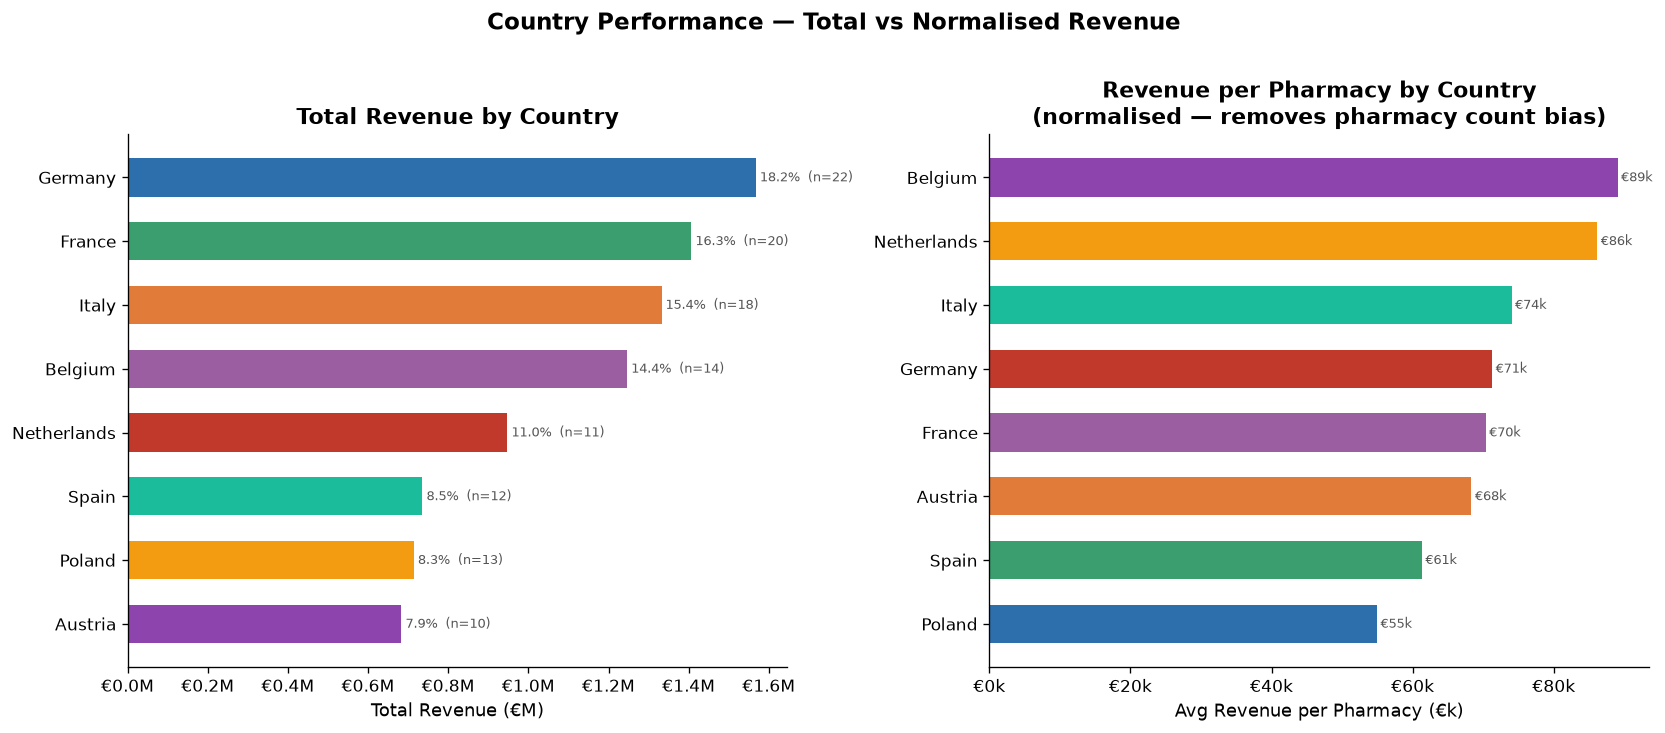

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_c = df_country.sort_values('total_revenue')
colors = COUNTRY_COLORS[::-1][:len(df_c)]

# ── Chart 1: Total revenue by country ───────────────────────────────
bars = axes[0].barh(df_c['country'], df_c['total_revenue'] / 1e6,
                    color=colors, height=0.6)
axes[0].set_xlabel('Total Revenue (€M)')
axes[0].set_title('Total Revenue by Country')
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.1fM'))

for bar, row in zip(bars, df_c.itertuples()):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{row.revenue_share_pct}%  (n={row.pharmacy_count})',
                 va='center', fontsize=8, color='#555')

# ── Chart 2: Avg revenue per pharmacy (normalised) ──────────────────
df_norm = df_country.sort_values('avg_rev_per_pharmacy')
norm_colors = COUNTRY_COLORS[:len(df_norm)]

bars2 = axes[1].barh(df_norm['country'], df_norm['avg_rev_per_pharmacy'] / 1e3,
                     color=norm_colors, height=0.6)
axes[1].set_xlabel('Avg Revenue per Pharmacy (€k)')
axes[1].set_title('Revenue per Pharmacy by Country\n(normalised — removes pharmacy count bias)')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

for bar, val in zip(bars2, df_norm['avg_rev_per_pharmacy']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'€{val/1e3:.0f}k', va='center', fontsize=8, color='#555')

plt.suptitle('Country Performance — Total vs Normalised Revenue',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/01_country_performance.png', bbox_inches='tight')
plt.show()

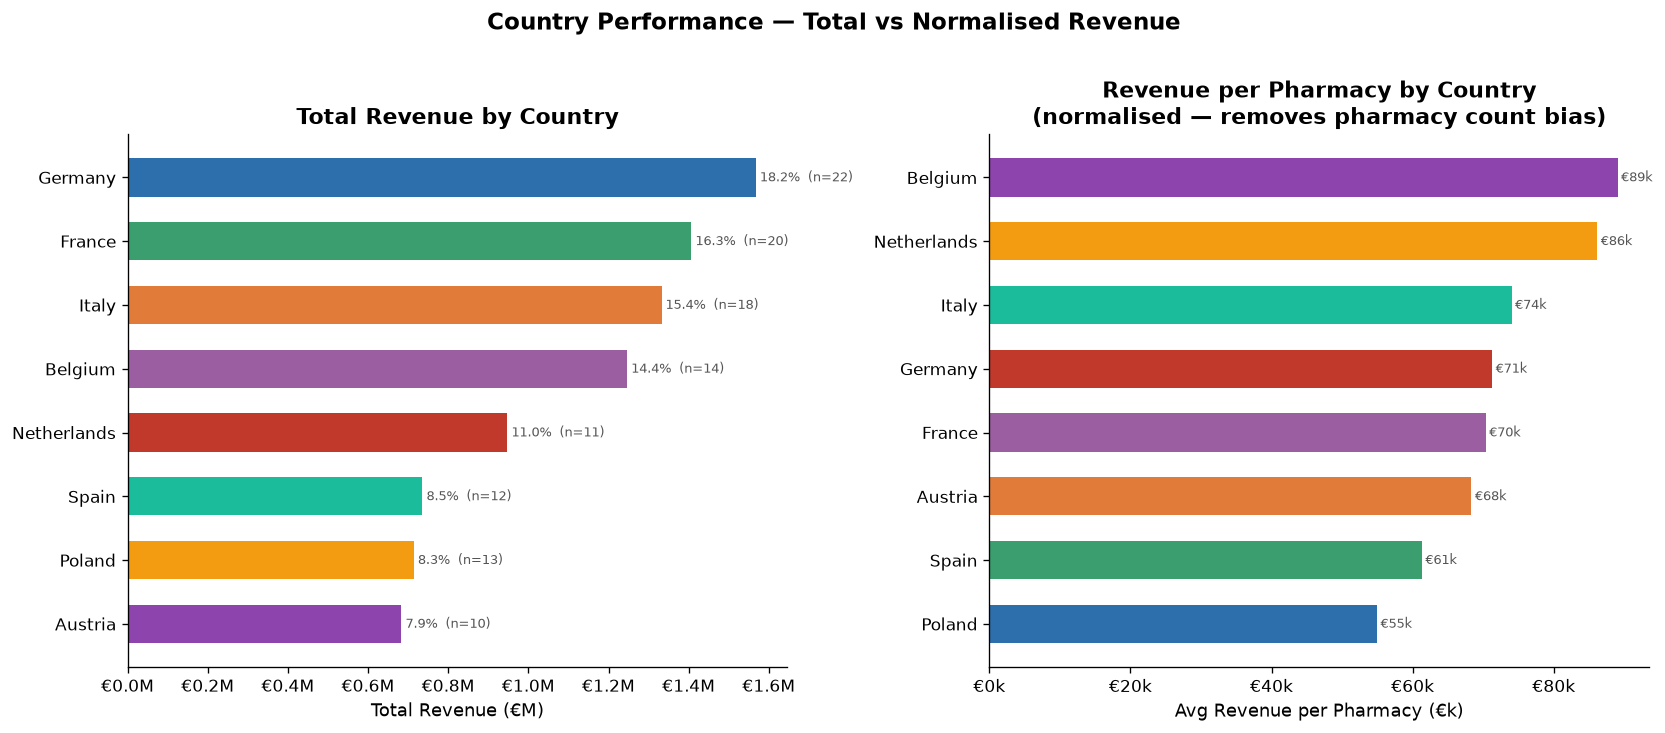

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_c = df_country.sort_values('total_revenue')
colors = COUNTRY_COLORS[::-1][:len(df_c)]

# ── Chart 1: Total revenue by country ───────────────────────────────
bars = axes[0].barh(df_c['country'], df_c['total_revenue'] / 1e6,
                    color=colors, height=0.6)
axes[0].set_xlabel('Total Revenue (€M)')
axes[0].set_title('Total Revenue by Country')
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.1fM'))

for bar, row in zip(bars, df_c.itertuples()):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{row.revenue_share_pct}%  (n={row.pharmacy_count})',
                 va='center', fontsize=8, color='#555')

# ── Chart 2: Avg revenue per pharmacy (normalised) ──────────────────
df_norm = df_country.sort_values('avg_rev_per_pharmacy')
norm_colors = COUNTRY_COLORS[:len(df_norm)]

bars2 = axes[1].barh(df_norm['country'], df_norm['avg_rev_per_pharmacy'] / 1e3,
                     color=norm_colors, height=0.6)
axes[1].set_xlabel('Avg Revenue per Pharmacy (€k)')
axes[1].set_title('Revenue per Pharmacy by Country\n(normalised — removes pharmacy count bias)')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

for bar, val in zip(bars2, df_norm['avg_rev_per_pharmacy']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'€{val/1e3:.0f}k', va='center', fontsize=8, color='#555')

plt.suptitle('Country Performance — Total vs Normalised Revenue',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/01_country_performance.png', bbox_inches='tight')
plt.show()

── Top 15 regions by revenue ──
    country                     region  pharmacy_count  transactions  total_revenue  total_margin  margin_pct  avg_rev_per_pharmacy
      Italy                   Lombardy               5          3512      507428.29     142605.04        28.1              101486.0
    Germany                    Hamburg               5          3066      478511.97     134181.05        28.0               95702.0
Netherlands                    Utrecht               4          2772      447640.52     124713.44        27.9              111910.0
    Belgium                   Wallonia               4          2632      428836.54     120030.15        28.0              107209.0
    Germany                    Bavaria               7          3013      422873.18     118353.82        28.0               60410.0
     France       Auvergne-Rhône-Alpes               5          2887      409453.35     115437.72        28.2               81891.0
Netherlands              South Holland      

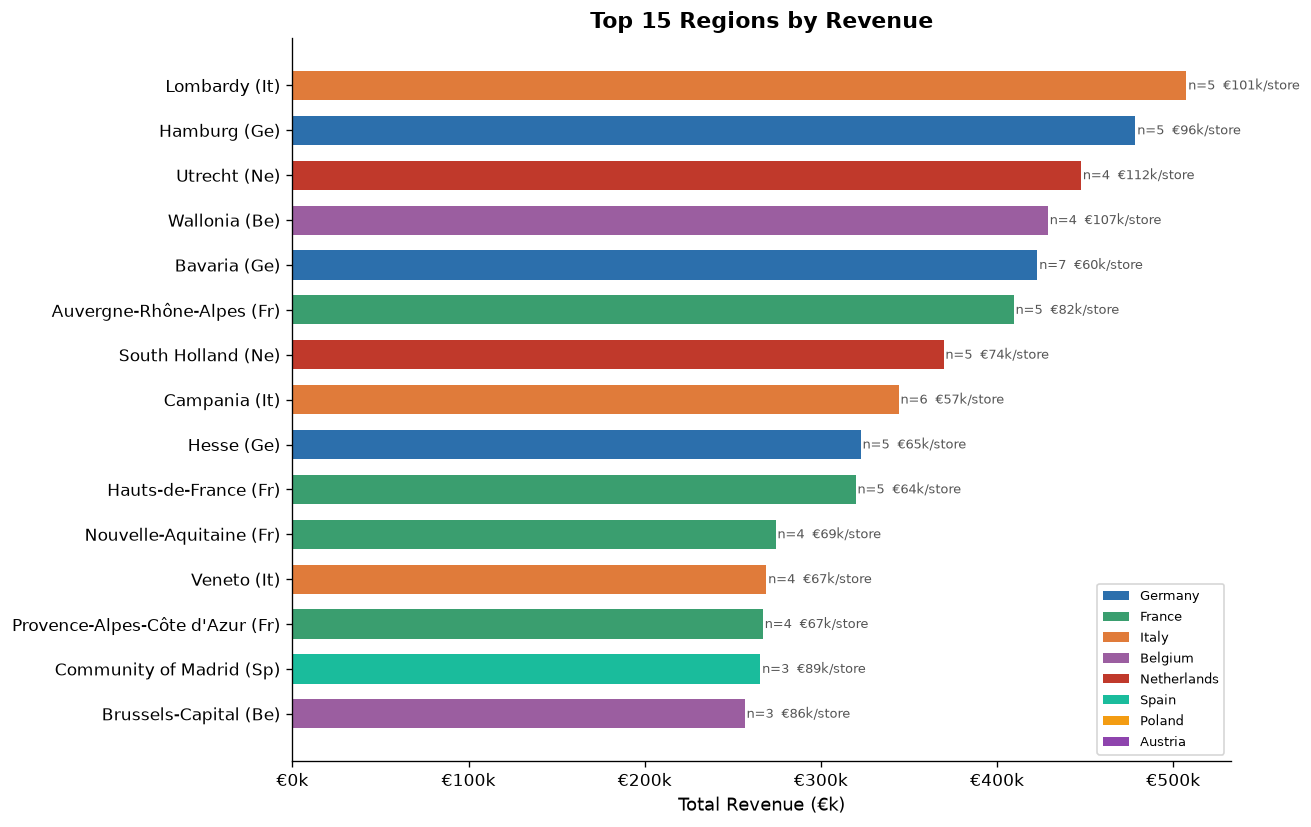

In [5]:
query_region = """
SELECT
    dp.country,
    dp.region,
    COUNT(DISTINCT dp.pharmacyid)                                AS pharmacy_count,
    COUNT(fs.salesid)                                            AS transactions,
    ROUND(SUM(fs.revenueeur), 2)                                 AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                                  AS total_margin,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)      AS margin_pct,
    ROUND(SUM(fs.revenueeur) / COUNT(DISTINCT dp.pharmacyid), 0) AS avg_rev_per_pharmacy
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.country, dp.region
ORDER BY total_revenue DESC
"""

df_region = run_query(query_region)

print("── Top 15 regions by revenue ──")
print(df_region.head(15).to_string(index=False))
# Top 15 regions chart
top15_regions = df_region.head(15).copy()
top15_regions['label'] = top15_regions['region'] + ' (' + top15_regions['country'].str[:2] + ')'
top15_regions = top15_regions.sort_values('total_revenue')

# Colour by country
country_color_map = dict(zip(df_country['country'], COUNTRY_COLORS))
bar_colors = [country_color_map.get(c, '#888') for c in top15_regions['country']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15_regions['label'], top15_regions['total_revenue'] / 1e3,
               color=bar_colors, height=0.65)
ax.set_xlabel('Total Revenue (€k)')
ax.set_title('Top 15 Regions by Revenue', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

for bar, row in zip(bars, top15_regions.itertuples()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'n={row.pharmacy_count}  €{row.avg_rev_per_pharmacy/1e3:.0f}k/store',
            va='center', fontsize=7.5, color='#555')

legend_elements = [Patch(facecolor=v, label=k) for k, v in country_color_map.items()]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('outputs/02_top_regions.png', bbox_inches='tight')
plt.show()

pharmacytype  pharmacy_count  transactions  total_units  total_revenue  total_margin  avg_revenue_per_tx  margin_pct  revenue_share_pct  avg_rev_per_pharmacy  avg_tx_per_pharmacy
       Urban              50         29552       212285     4125299.27    1154324.75              139.59        28.0               47.8               82506.0                  591
    Suburban              47         22403       158564     3109295.56     873866.68              138.79        28.1               36.0               66155.0                  476
       Rural              23         10184        74944     1399382.48     392949.64              137.41        28.1               16.2               60843.0                  442


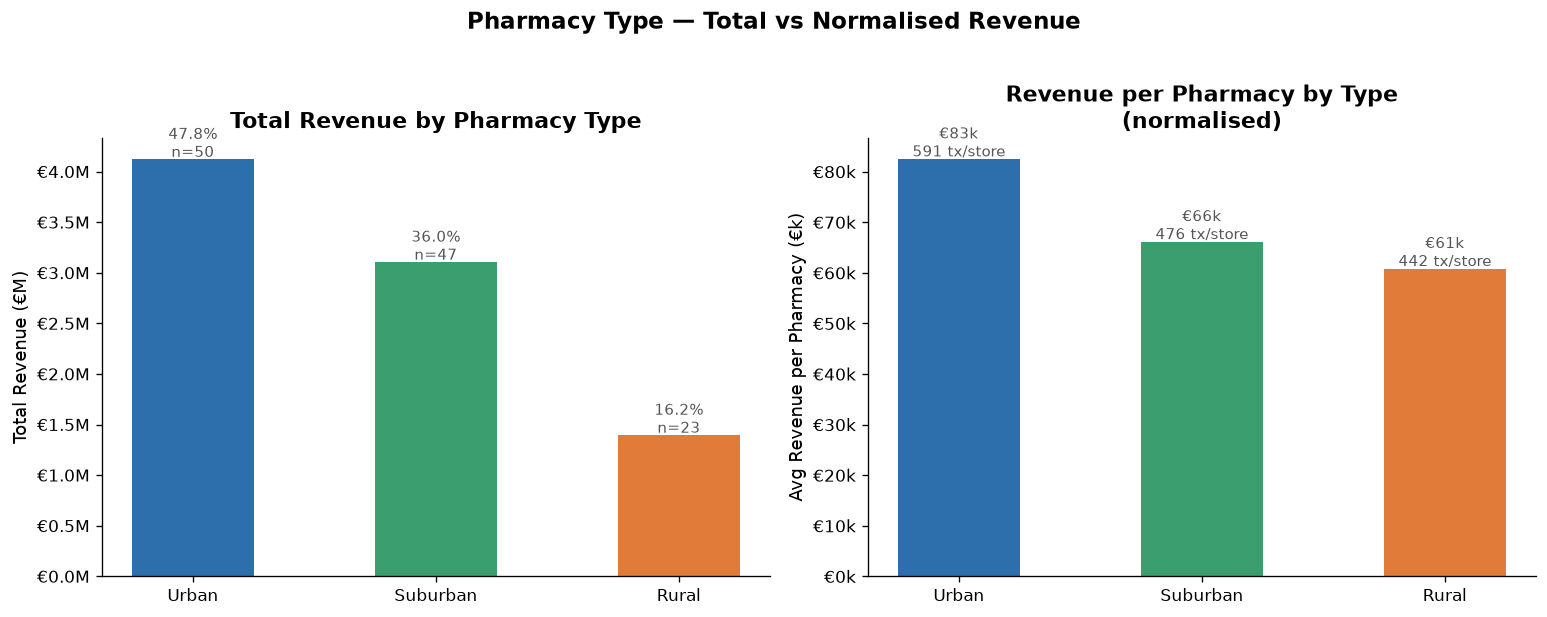

In [6]:
query_phtype = """
SELECT
    dp.pharmacytype,
    COUNT(DISTINCT dp.pharmacyid)                                            AS pharmacy_count,
    COUNT(fs.salesid)                                                        AS transactions,
    SUM(fs.unitssold)                                                        AS total_units,
    ROUND(SUM(fs.revenueeur), 2)                                             AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                                              AS total_margin,
    ROUND(AVG(fs.revenueeur), 2)                                             AS avg_revenue_per_tx,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)                  AS margin_pct,
    ROUND(SUM(fs.revenueeur) / SUM(SUM(fs.revenueeur)) OVER () * 100, 1)    AS revenue_share_pct,
    ROUND(SUM(fs.revenueeur) / COUNT(DISTINCT dp.pharmacyid), 0)             AS avg_rev_per_pharmacy,
    ROUND(COUNT(fs.salesid) / COUNT(DISTINCT dp.pharmacyid), 0)              AS avg_tx_per_pharmacy
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.pharmacytype
ORDER BY total_revenue DESC
"""

df_phtype = run_query(query_phtype)
print(df_phtype.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ph_types = df_phtype['pharmacytype'].tolist()
ph_colors = [TYPE_COLORS[t] for t in ph_types]

# ── Chart 1: Total revenue by pharmacy type ──────────────────────────
bars = axes[0].bar(ph_types, df_phtype['total_revenue'] / 1e6,
                   color=ph_colors, width=0.5)
axes[0].set_ylabel('Total Revenue (€M)')
axes[0].set_title('Total Revenue by Pharmacy Type')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.1fM'))

for bar, row in zip(bars, df_phtype.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f'{row.revenue_share_pct}%\nn={row.pharmacy_count}',
                 ha='center', fontsize=9, color='#555')

# ── Chart 2: Avg revenue per pharmacy (normalised) ──────────────────
bars2 = axes[1].bar(ph_types, df_phtype['avg_rev_per_pharmacy'] / 1e3,
                    color=ph_colors, width=0.5)
axes[1].set_ylabel('Avg Revenue per Pharmacy (€k)')
axes[1].set_title('Revenue per Pharmacy by Type\n(normalised)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

for bar, row in zip(bars2, df_phtype.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'€{row.avg_rev_per_pharmacy/1e3:.0f}k\n{row.avg_tx_per_pharmacy:.0f} tx/store',
                 ha='center', fontsize=9, color='#555')

plt.suptitle('Pharmacy Type — Total vs Normalised Revenue',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/03_pharmacy_type_performance.png', bbox_inches='tight')
plt.show()

storesizeband  pharmacy_count  transactions  total_revenue  total_margin  avg_revenue_per_tx  margin_pct  avg_rev_per_pharmacy  avg_tx_per_pharmacy size_label
            L              25         19781     3172447.08     890224.58              160.38        28.1              126898.0                  791      Large
            M              53         28181     3835577.81    1075037.57              136.11        28.0               72369.0                  531     Medium
            S              42         14177     1625952.42     455878.92              114.69        28.0               38713.0                  337      Small


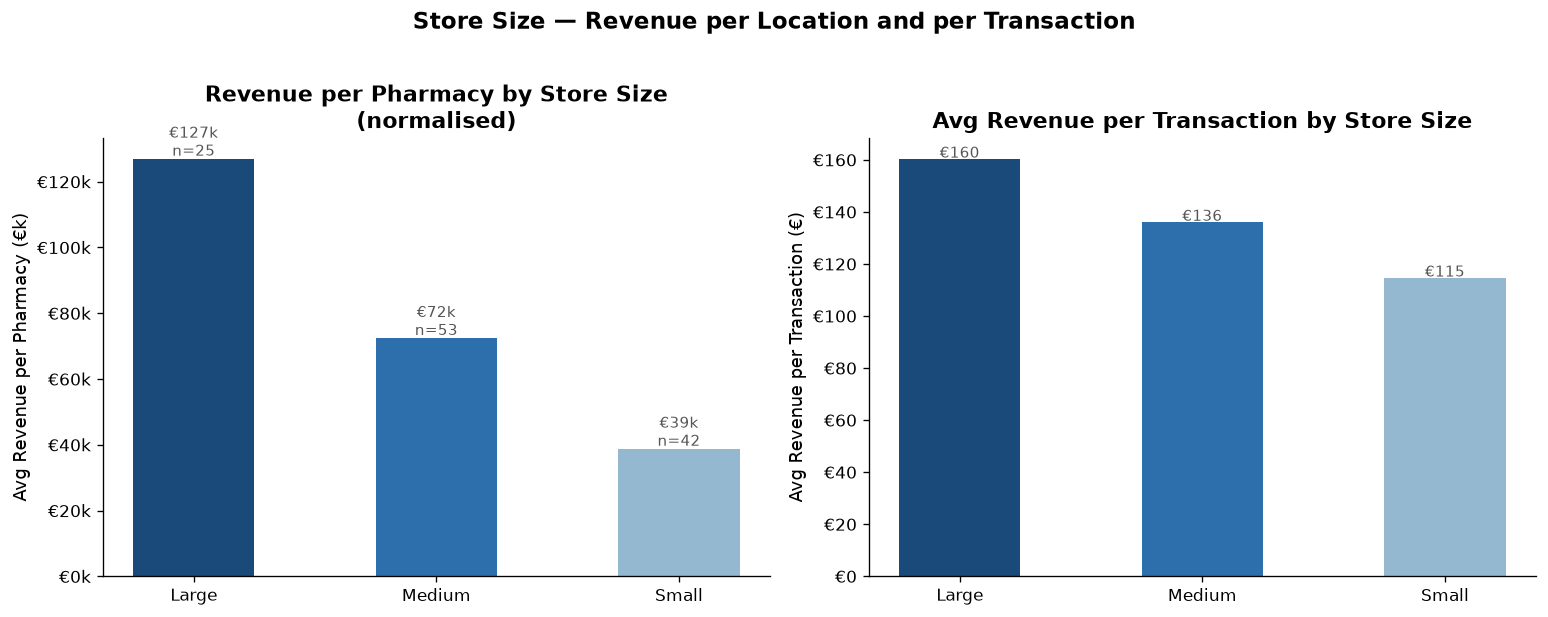

In [7]:
query_size = """
SELECT
    dp.storesizeband,
    COUNT(DISTINCT dp.pharmacyid)                                            AS pharmacy_count,
    COUNT(fs.salesid)                                                        AS transactions,
    ROUND(SUM(fs.revenueeur), 2)                                             AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                                             AS total_margin,
    ROUND(AVG(fs.revenueeur), 2)                                             AS avg_revenue_per_tx,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1)                  AS margin_pct,
    ROUND(SUM(fs.revenueeur) / COUNT(DISTINCT dp.pharmacyid), 0)             AS avg_rev_per_pharmacy,
    ROUND(COUNT(fs.salesid) / COUNT(DISTINCT dp.pharmacyid), 0)              AS avg_tx_per_pharmacy
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.storesizeband
ORDER BY avg_rev_per_pharmacy DESC
"""

df_size = run_query(query_size)
df_size['size_label'] = df_size['storesizeband'].map({'L': 'Large', 'M': 'Medium', 'S': 'Small'})
print(df_size.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

size_order  = ['Large', 'Medium', 'Small']
df_size_s   = df_size.set_index('size_label').reindex(size_order).reset_index()
size_colors = ['#1a4a7a', '#2C6FAC', '#95b8d1']

# ── Chart 1: Avg revenue per pharmacy by size ────────────────────────
bars = axes[0].bar(df_size_s['size_label'],
                   df_size_s['avg_rev_per_pharmacy'] / 1e3,
                   color=size_colors, width=0.5)
axes[0].set_ylabel('Avg Revenue per Pharmacy (€k)')
axes[0].set_title('Revenue per Pharmacy by Store Size\n(normalised)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

for bar, row in zip(bars, df_size_s.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'€{row.avg_rev_per_pharmacy/1e3:.0f}k\nn={row.pharmacy_count}',
                 ha='center', fontsize=9, color='#555')

# ── Chart 2: Avg revenue per transaction by size ─────────────────────
bars2 = axes[1].bar(df_size_s['size_label'],
                    df_size_s['avg_revenue_per_tx'],
                    color=size_colors, width=0.5)
axes[1].set_ylabel('Avg Revenue per Transaction (€)')
axes[1].set_title('Avg Revenue per Transaction by Store Size')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0f'))

for bar, row in zip(bars2, df_size_s.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'€{row.avg_revenue_per_tx:.0f}',
                 ha='center', fontsize=9, color='#555')

plt.suptitle('Store Size — Revenue per Location and per Transaction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/04_store_size_performance.png', bbox_inches='tight')
plt.show()

── Top 10 pharmacies by revenue ──
              pharmacyname     country pharmacytype size_label  transactions  total_revenue  margin_pct
   Munich HealthPoint #095     Germany        Urban      Large           919      162320.29        27.8
Rotterdam HealthPoint #023 Netherlands        Urban      Large           896      159495.01        27.7
  Utrecht HealthPoint #058 Netherlands        Urban      Large           881      158935.66        27.5
 Brussels HealthPoint #078     Belgium        Urban      Large           887      151533.96        28.4
    Liège HealthPoint #010     Belgium        Urban      Large           855      147924.27        27.9
     Lyon HealthPoint #073      France        Urban      Large           844      143722.53        28.0
Frankfurt HealthPoint #055     Germany     Suburban      Large           775      137422.29        28.3
  Antwerp HealthPoint #109     Belgium        Urban      Large           840      135770.62        28.1
   Vienna HealthPoint #074   

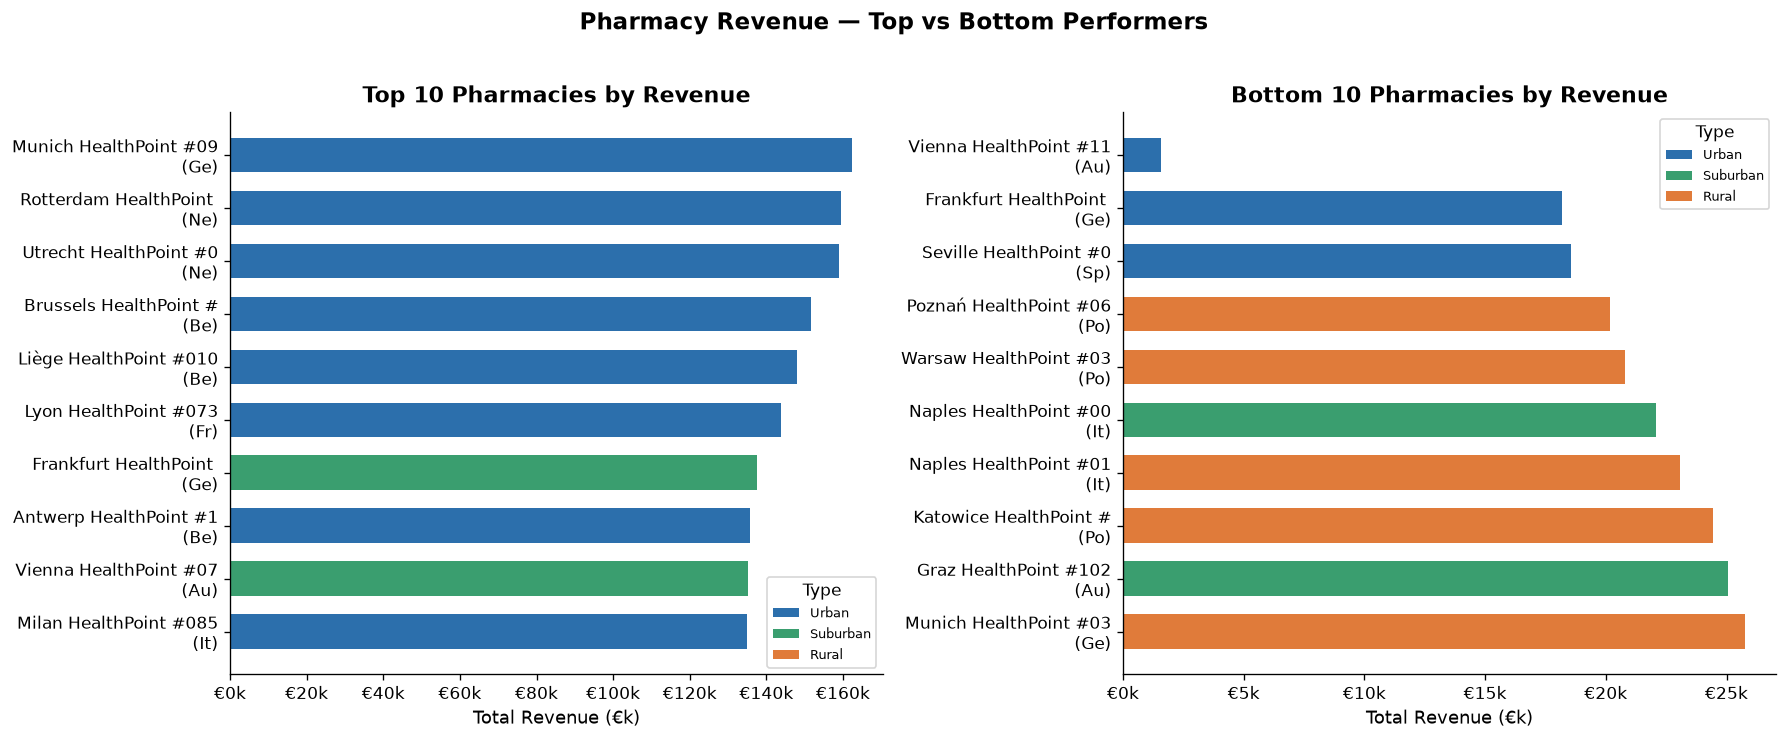

In [8]:
query_all_pharmacies = """
SELECT
    dp.pharmacyid,
    dp.pharmacyname,
    dp.country,
    dp.city,
    dp.pharmacytype,
    dp.storesizeband,
    dp.latitude,
    dp.longitude,
    COUNT(fs.salesid)                                       AS transactions,
    SUM(fs.unitssold)                                       AS total_units,
    ROUND(SUM(fs.revenueeur), 2)                            AS total_revenue,
    ROUND(SUM(fs.margineur), 2)                             AS total_margin,
    ROUND(SUM(fs.margineur) / SUM(fs.revenueeur) * 100, 1) AS margin_pct
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.pharmacyid, dp.pharmacyname, dp.country, dp.city,
         dp.pharmacytype, dp.storesizeband, dp.latitude, dp.longitude
ORDER BY total_revenue DESC
"""

df_all_ph = run_query(query_all_pharmacies)
df_all_ph['size_label'] = df_all_ph['storesizeband'].map({'L': 'Large', 'M': 'Medium', 'S': 'Small'})

print("── Top 10 pharmacies by revenue ──")
print(df_all_ph.head(10)[['pharmacyname','country','pharmacytype','size_label',
                            'transactions','total_revenue','margin_pct']].to_string(index=False))
print()
print("── Bottom 10 pharmacies by revenue ──")
print(df_all_ph.tail(10)[['pharmacyname','country','pharmacytype','size_label',
                            'transactions','total_revenue','margin_pct']].to_string(index=False))
# Top 10 and bottom 10 side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top10  = df_all_ph.head(10).sort_values('total_revenue')
bot10  = df_all_ph.tail(10).sort_values('total_revenue', ascending=False)

top_colors = [TYPE_COLORS[t] for t in top10['pharmacytype']]
bot_colors = [TYPE_COLORS[t] for t in bot10['pharmacytype']]

# Top 10
top10['short'] = top10['pharmacyname'].str[:22] + '\n(' + top10['country'].str[:2] + ')'
axes[0].barh(top10['short'], top10['total_revenue'] / 1e3,
             color=top_colors, height=0.65)
axes[0].set_xlabel('Total Revenue (€k)')
axes[0].set_title('Top 10 Pharmacies by Revenue', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

# Bottom 10
bot10['short'] = bot10['pharmacyname'].str[:22] + '\n(' + bot10['country'].str[:2] + ')'
axes[1].barh(bot10['short'], bot10['total_revenue'] / 1e3,
             color=bot_colors, height=0.65)
axes[1].set_xlabel('Total Revenue (€k)')
axes[1].set_title('Bottom 10 Pharmacies by Revenue', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.0fk'))

legend_elements = [Patch(facecolor=v, label=k) for k, v in TYPE_COLORS.items()]
for ax in axes:
    ax.legend(handles=legend_elements, fontsize=8, title='Type')

plt.suptitle('Pharmacy Revenue — Top vs Bottom Performers',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/05_top_bottom_pharmacies.png', bbox_inches='tight')
plt.show()

── Avg revenue per pharmacy by country x type (€) ──
pharmacytype     Urban  Suburban    Rural
country                                  
Austria        52138.0   79122.0      0.0
Belgium       111572.0   64810.0  94111.0
France         85017.0   68074.0  60198.0
Germany        80281.0   66773.0  69703.0
Italy          82110.0   68105.0  56842.0
Netherlands   116498.0   45205.0  67943.0
Poland         60881.0   95466.0  42247.0
Spain          65024.0   56087.0      0.0


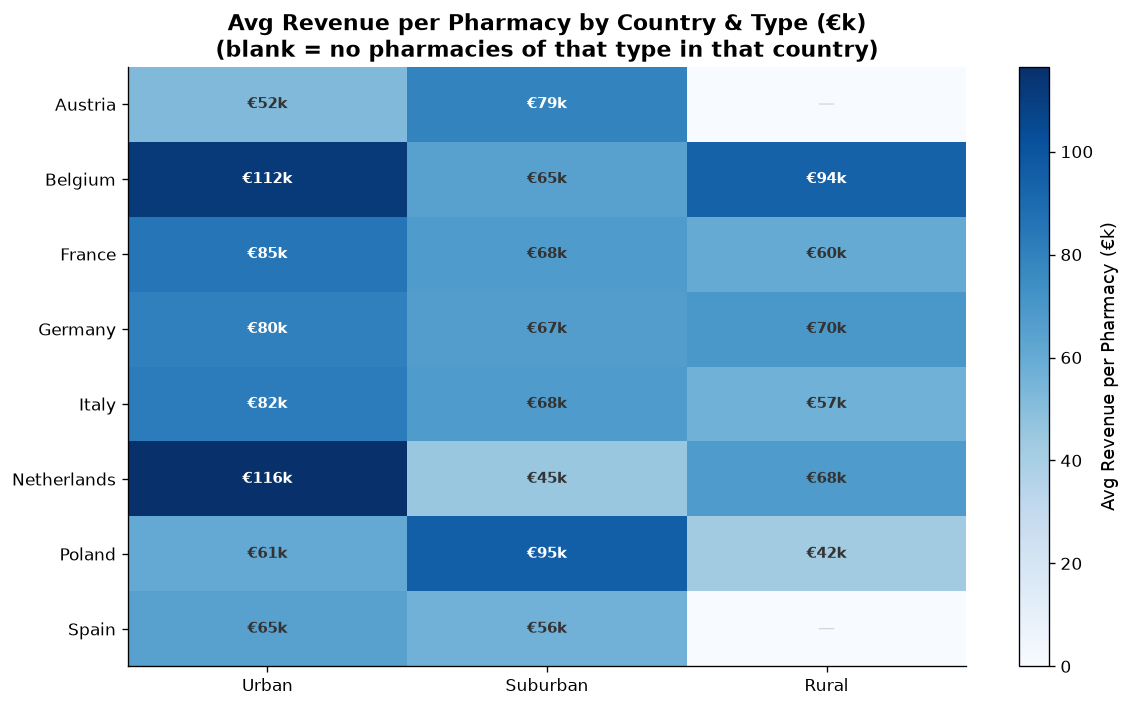

In [9]:
query_cross = """
SELECT
    dp.country,
    dp.pharmacytype,
    COUNT(DISTINCT dp.pharmacyid)                                AS pharmacy_count,
    ROUND(SUM(fs.revenueeur), 2)                                 AS total_revenue,
    ROUND(SUM(fs.revenueeur) / COUNT(DISTINCT dp.pharmacyid), 0) AS avg_rev_per_pharmacy
FROM fact_sales fs
JOIN dim_pharmacy dp ON fs.pharmacyid = dp.pharmacyid
GROUP BY dp.country, dp.pharmacytype
ORDER BY dp.country, dp.pharmacytype
"""

df_cross = run_query(query_cross)

# Pivot to heatmap
pivot = df_cross.pivot(index='country', columns='pharmacytype', values='avg_rev_per_pharmacy').fillna(0)
pivot = pivot[['Urban', 'Suburban', 'Rural']]

print("── Avg revenue per pharmacy by country x type (€) ──")
print(pivot.to_string())
fig, ax = plt.subplots(figsize=(10, 6))

data = pivot.values / 1e3
rows = pivot.index.tolist()
cols = pivot.columns.tolist()

im = ax.imshow(data, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)
ax.set_title('Avg Revenue per Pharmacy by Country & Type (€k)\n(blank = no pharmacies of that type in that country)',
             fontweight='bold')

for i in range(len(rows)):
    for j in range(len(cols)):
        val = data[i, j]
        if val > 0:
            text_color = 'white' if val > data.max() * 0.6 else '#333'
            ax.text(j, i, f'€{val:.0f}k', ha='center', va='center',
                    fontsize=9, color=text_color, fontweight='bold')
        else:
            ax.text(j, i, '—', ha='center', va='center',
                    fontsize=10, color='#ccc')

plt.colorbar(im, ax=ax, label='Avg Revenue per Pharmacy (€k)')
plt.tight_layout()
plt.savefig('outputs/06_country_type_heatmap.png', bbox_inches='tight')
plt.show()

In [10]:
# Full pharmacy-level data with coordinates for Tableau map
df_tableau_map = df_all_ph[[
    'pharmacyid', 'pharmacyname', 'country', 'city',
    'pharmacytype', 'size_label', 'latitude', 'longitude',
    'transactions', 'total_revenue', 'total_margin', 'margin_pct'
]].copy()

df_tableau_map.rename(columns={'size_label': 'store_size'}, inplace=True)

# Revenue band for colour coding in Tableau
df_tableau_map['revenue_band'] = pd.cut(
    df_tableau_map['total_revenue'],
    bins=[0, 50000, 80000, 110000, 140000, 200000],
    labels=['<€50k', '€50-80k', '€80-110k', '€110-140k', '>€140k']
)

print(f"Rows in map export: {len(df_tableau_map)}")
print(df_tableau_map.head(5).to_string(index=False))

Rows in map export: 120
pharmacyid               pharmacyname     country      city pharmacytype store_size  latitude  longitude  transactions  total_revenue  total_margin  margin_pct revenue_band
    PH0095    Munich HealthPoint #095     Germany    Munich        Urban      Large 48.152123  11.580034           919      162320.29      45172.56        27.8       >€140k
    PH0023 Rotterdam HealthPoint #023 Netherlands Rotterdam        Urban      Large 51.943687   4.478365           896      159495.01      44152.23        27.7       >€140k
    PH0058   Utrecht HealthPoint #058 Netherlands   Utrecht        Urban      Large 52.106746   5.103218           881      158935.66      43683.53        27.5       >€140k
    PH0078  Brussels HealthPoint #078     Belgium  Brussels        Urban      Large 50.852878   4.346851           887      151533.96      43046.24        28.4       >€140k
    PH0010     Liège HealthPoint #010     Belgium     Liège        Urban      Large 50.615562   5.574039       

In [11]:
# Country level
df_country.to_csv('../../data/processed/geo_country.csv', index=False)

# Region level
df_region.to_csv('../../data/processed/geo_region.csv', index=False)

# Pharmacy type
df_phtype.to_csv('../../data/processed/geo_pharmacy_type.csv', index=False)

# Store size
df_size.to_csv('../../data/processed/geo_store_size.csv', index=False)

# All pharmacies with coordinates (for Tableau map)
df_tableau_map.to_csv('../../data/processed/geo_pharmacy_map.csv', index=False)

# Country x pharmacy type cross
df_cross.to_csv('../../data/processed/geo_country_x_type.csv', index=False)

print("All CSVs exported to data/processed/")
print()
print("Files created:")
print("  geo_country.csv")
print("  geo_region.csv")
print("  geo_pharmacy_type.csv")
print("  geo_store_size.csv")
print("  geo_pharmacy_map.csv          ← connect to Tableau map view")
print("  geo_country_x_type.csv")

All CSVs exported to data/processed/

Files created:
  geo_country.csv
  geo_region.csv
  geo_pharmacy_type.csv
  geo_store_size.csv
  geo_pharmacy_map.csv          ← connect to Tableau map view
  geo_country_x_type.csv


In [12]:
summary = """
MODULE 4 — GEOGRAPHIC & PHARMACY SEGMENTATION
==============================================

COUNTRY FINDINGS
----------------
- Germany leads total revenue (18.2%, €1.57M) — 22 pharmacies
- Belgium leads revenue per pharmacy (€89,036) — most productive market
- Netherlands ranks 2nd on revenue per pharmacy (€86,159) — 11 stores
  punching well above their count
- Poland ranks last on revenue per pharmacy (€54,941) — 13 stores
  underperforming relative to their count
- Margin % is consistent across all 8 countries (27.8–28.2%)
- Country revenue ranking mirrors pharmacy count — normalised view
  is the meaningful comparison

REGION FINDINGS
---------------
- Lombardy (Italy): top region by revenue (€507k, 5 pharmacies, €101k/store)
- Hamburg (Germany): 2nd (€479k, 5 pharmacies, €96k/store)
- Utrecht (Netherlands): highest revenue per pharmacy of any region (€112k/store)
- Bavaria (Germany) ranks 5th in total but lower in per-store (€60k) — diluted
  by having 7 pharmacies spread across a large region

PHARMACY TYPE FINDINGS
----------------------
- Urban: €82,506 avg revenue per pharmacy — 35.6% more productive than Rural
- Suburban: €66,155 per pharmacy
- Rural: €60,843 per pharmacy
- Margin % consistent across all types (28.0–28.1%)
- Urban stores handle more transactions per store (591 avg tx/store)

STORE SIZE FINDINGS
-------------------
- Large stores: €126,898 avg revenue per pharmacy — 3.3x more than Small
- Large stores: avg €160.38 revenue per transaction — 40% more than Small (€114.69)
- Large stores likely handle proportionally more high-value Prescription transactions
- All top 10 pharmacies are Large stores — consistent with size findings
- Margin % consistent across all sizes

PHARMACY-LEVEL FINDINGS
-----------------------
- Top pharmacy: Munich HealthPoint #095 — €162k revenue, Urban, Large
- All top 10 pharmacies are Large stores
- Bottom pharmacy (PH0115, Vienna) — 16 transactions, likely data anomaly
- Bottom performers are Small stores in Rural/Suburban Poland and Austria

CHARTS SAVED
------------
  outputs/01_country_performance.png
  outputs/02_top_regions.png
  outputs/03_pharmacy_type_performance.png
  outputs/04_store_size_performance.png
  outputs/05_top_bottom_pharmacies.png
  outputs/06_country_type_heatmap.png

CSVs EXPORTED
-------------
  data/processed/geo_country.csv
  data/processed/geo_region.csv
  data/processed/geo_pharmacy_type.csv
  data/processed/geo_store_size.csv
  data/processed/geo_pharmacy_map.csv
  data/processed/geo_country_x_type.csv
"""

print(summary)


MODULE 4 — GEOGRAPHIC & PHARMACY SEGMENTATION

COUNTRY FINDINGS
----------------
- Germany leads total revenue (18.2%, €1.57M) — 22 pharmacies
- Belgium leads revenue per pharmacy (€89,036) — most productive market
- Netherlands ranks 2nd on revenue per pharmacy (€86,159) — 11 stores
  punching well above their count
- Poland ranks last on revenue per pharmacy (€54,941) — 13 stores
  underperforming relative to their count
- Margin % is consistent across all 8 countries (27.8–28.2%)
- Country revenue ranking mirrors pharmacy count — normalised view
  is the meaningful comparison

REGION FINDINGS
---------------
- Lombardy (Italy): top region by revenue (€507k, 5 pharmacies, €101k/store)
- Hamburg (Germany): 2nd (€479k, 5 pharmacies, €96k/store)
- Utrecht (Netherlands): highest revenue per pharmacy of any region (€112k/store)
- Bavaria (Germany) ranks 5th in total but lower in per-store (€60k) — diluted
  by having 7 pharmacies spread across a large region

PHARMACY TYPE FINDINGS
-----